In [25]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
%matplotlib widget

In [26]:
df = pd.read_csv('../Datasets/scrap price.csv')

In [27]:
df.head()

,ID,symboling,name,fueltypes,aspiration,doornumbers,carbody,drivewheels,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [45]:
# Matriz de características X y vector objetivo y
X = df[["enginesize", "horsepower"]].values
y = df["price"].values.reshape(-1, 1)
y = y[: None]
print(X.shape)
print(y.shape)

(205, 2)
(205, 1)


In [29]:
## Z-score estandarización o normalización
m = np.mean(X, axis=0)
std = np.std(X, axis=0)
X = (X - m) / std

In [30]:
# sesgo (bias)
X_b = np.c_[np.ones((len(X), 1)), X]

### Regresión Lineal Ponderada Localmente (LWLR)

A diferencia de la regresión lineal tradicional, la **Regresión Lineal Ponderada Localmente** es un algoritmo *no paramétrico* que realiza una estimación distinta para cada punto de consulta ($x$), dando mayor peso a los datos cercanos.

#### 1. La Ecuación Normal Ponderada

Para obtener los parámetros $\theta$ optimizados para un punto específico $x$, resolvemos la siguiente ecuación matricial:

$$\theta = (X^T W X)^{-1} X^T W y$$

Donde:
* **$X$**: Es la matriz de características (incluyendo la columna de unos para el intercepto).
* **$y$**: Es el vector de etiquetas o valores objetivo.
* **$W$**: Es una **matriz diagonal de pesos** de tamaño $m \times m$.

---

### 2. Cálculo de la Matriz de Pesos ($W$)

Cada elemento de la diagonal $w^{(i)}$ determina cuánta influencia tiene el dato $i$-ésimo en la predicción del punto actual $x$. Se utiliza comúnmente el **Kernel Gaussiano**:

$$w^{(i)} = \exp\left(-\frac{(x^{(i)} - x)^2}{2k^2}\right)$$

#### Parámetros clave:
* **$|x^{(i)} - x|$**: Es la distancia entre el punto de entrenamiento y el punto que queremos predecir.
* **$k$ (o $\tau$)**: Es el parámetro de **ancho de banda**. 
    * Si $k$ es **pequeño**, solo los puntos muy cercanos tienen peso (riesgo de *overfitting*).
    * Si $k$ es **grande**, los puntos lejanos también influyen (el modelo se vuelve similar a una regresión lineal global).

> **Nota:** La matriz $W$ se construye de forma que $W_{ii} = w^{(i)}$ y todos los demás elementos sean cero.

In [31]:

def matrix_pesos(punto, X, k):
    m = X.shape[0]
    weights = np.eye(m) # Matriz identidad de tamaño m x m (ceros)
    
    for i in range(m):
        diff = punto - X[i]
        # Aplicamos la fórmula del kernel gaussiano
        weights[i, i] = np.exp(np.dot(diff, diff.T) / (-2.0 * k**2))
    
    return weights

In [32]:
def predict(X, y, punto, k):
    W = matrix_pesos(punto, X, k)
    # Ecuación Normal: theta = (X.T * W * X)^-1 * X.T * W * y
    xtwx = X.T @ (W @ X)
    theta = np.linalg.pinv(xtwx) @ (X.T @ (W @ y))
    # print(theta)
    return punto @ theta

In [54]:
# parámetro de suavizado
k = 0.001

y_pred = []
for i in range(len(X_b)):
    prediction = predict(X_b, y, X_b[i], k)
    y_pred.append(prediction[0])
    
df['prediction'] = y_pred
df.head()

,ID,symboling,name,fueltypes,aspiration,doornumbers,carbody,drivewheels,enginelocation,wheelbase,...,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,prediction
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,14997.5
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,14997.5
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,17450.0


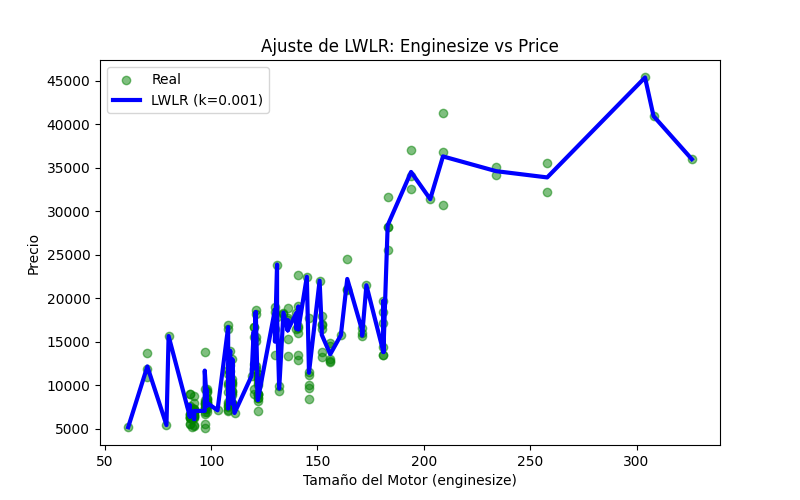

In [57]:
plt.figure(figsize=(8, 5))
plt.scatter(df['enginesize'], df['price'], color='green', alpha=0.5, label='Real')
df_sorted = df.sort_values(by='enginesize')
plt.plot(df_sorted['enginesize'], df_sorted['prediction'], color='blue', lw=3, label=f'LWLR (k={k})')
plt.xlabel('Tamaño del Motor (enginesize)')
plt.ylabel('Precio')
plt.title('Ajuste de LWLR: Enginesize vs Price')
plt.legend()
plt.show()